In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Function to reduce the size of the Datasets
def reduce_size(dataset):
  df = pd.read_csv(dataset)
  df_short = df[(df['hours'] > 5)]
  return df_short,df.size,df_short.size

In [ ]:
#Reducing size of datasets month wise
new_info = {"Datasets":['Jan','Feb','Mar','Apr','May','June','July','Aug','Sep','Oct','Nov','Dec'],'actual_size':[],'new_size':[]}
datasets = []
for i in range(1,13):
  if i < 10:
    df,a,b = reduce_size(f'Datasets/fleet-monthly-csvs-10-v3-2024-0{i}-01.csv')
    new_info['actual_size'].append(a)
    new_info['new_size'].append(b)
    df.to_csv(f'Datasets/fleet_{i}.csv',index=False)
  else:
    df,a,b = reduce_size(f'Datasets/fleet-monthly-csvs-10-v3-2024-{i}-01.csv')
    new_info['actual_size'].append(a)
    new_info['new_size'].append(b)
    df.to_csv(f'Datasets/fleet_{i}.csv',index=False)
  datasets.append(f'fleet_{i}.csv')

In [ ]:
new_info = pd.DataFrame(new_info)
new_info


,Datasets,actual_size,new_size
0,Jan,10809180,2584410
1,Feb,10234790,2392400
2,Mar,11585910,2927280
3,Apr,12173430,3006070
4,May,12364150,2617820
5,June,11736540,2554870
6,July,11588110,2575740
7,Aug,11942440,2895380
8,Sep,11774360,2959720
9,Oct,11918780,2967810


<Axes: xlabel='Datasets'>

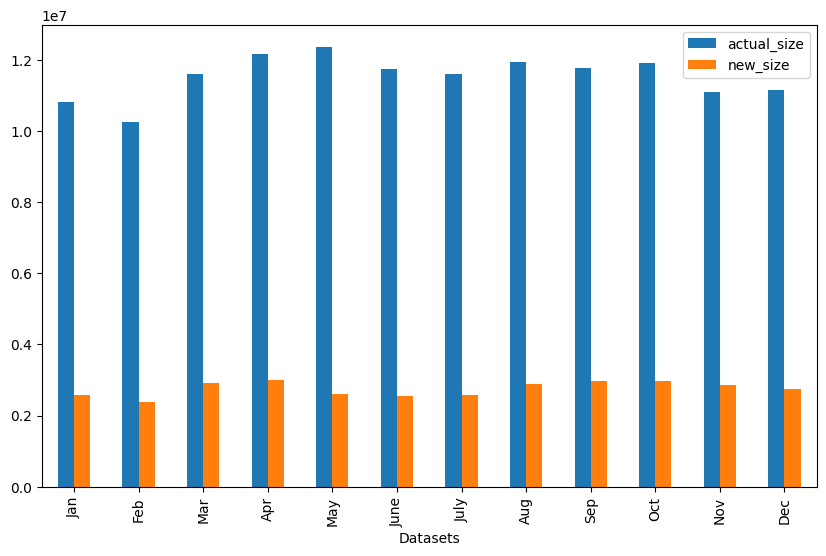

In [ ]:
new_info.plot(x='Datasets',y=['actual_size','new_size'],kind='bar',figsize=(10,6))

In [ ]:
#Funtions  to combine all datasets into Master datasets
def combine_datasets(datasets):
  df_list = []
  for i in range(len(datasets)):
    df = pd.read_csv(f'Datasets/{datasets[i]}')
    df_list.append(df)
  combined_dataset = pd.concat(df_list,ignore_index=True)
  return combined_dataset




In [ ]:
final_df = combine_datasets(datasets)

In [ ]:
final_df.head()

,date,year,month,cell_ll_lat,cell_ll_lon,flag,geartype,hours,fishing_hours,mmsi_present
0,2024-01-01,2024,1,4.1,100.0,AFG,trawlers,22.9463,22.7075,1
1,2024-01-01,2024,1,4.2,100.0,AFG,trawlers,29.7680,29.7161,1
2,2024-01-01,2024,1,4.3,99.9,AFG,trawlers,6.4155,6.4155,1
3,2024-01-01,2024,1,4.4,99.9,AFG,trawlers,7.3788,6.7413,1
4,2024-01-01,2024,1,23.5,117.7,AFG,fishing,15.8074,6.7811,1


In [ ]:
print("Actual Combined Size : ",sum(new_info['actual_size']))
print("Reduced Combined Size : ",final_df.size)

Actual Combined Size :  138386190
Reduced Combined Size :  36410165


In [ ]:
final_df.drop(['date','year'],axis=1,inplace=True)
final_df['loitering_time'] = (final_df['hours'] - final_df['fishing_hours'])
final_df['loiter_ratio'] = (final_df['loitering_time']/final_df['hours']).round(4)
final_df['loitering'] = (final_df['loiter_ratio'] > 0.5).astype(int)
final_df.rename(columns={'cell_ll_lat':'lat','cell_ll_lon':'lon'},inplace=True)


In [ ]:
final_df.head()

,month,lat,lon,flag,geartype,hours,fishing_hours,mmsi_present,loitering_time,loiter_ratio,loitering
0,1,4.1,100.0,AFG,trawlers,22.9463,22.7075,1,0.2388,0.0104,0
1,1,4.2,100.0,AFG,trawlers,29.7680,29.7161,1,0.0519,0.0017,0
2,1,4.3,99.9,AFG,trawlers,6.4155,6.4155,1,0.0000,0.0000,0
3,1,4.4,99.9,AFG,trawlers,7.3788,6.7413,1,0.6375,0.0864,0
4,1,23.5,117.7,AFG,fishing,15.8074,6.7811,1,9.0263,0.5710,1


In [ ]:
final_df.to_csv('Datasets/combined_dataset.csv',index=False)

In [3]:
com_df = pd.read_csv('Datasets/combined_dataset.csv')

In [4]:
com_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3310015 entries, 0 to 3310014
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   month           int64  
 1   lat             float64
 2   lon             float64
 3   flag            object 
 4   geartype        object 
 5   hours           float64
 6   fishing_hours   float64
 7   mmsi_present    int64  
 8   loitering_time  float64
 9   loiter_ratio    float64
 10  loitering       int64  
dtypes: float64(6), int64(3), object(2)
memory usage: 277.8+ MB


In [5]:
com_df.describe()

,month,lat,lon,hours,fishing_hours,mmsi_present,loitering_time,loiter_ratio,loitering
count,3.310015e+06,3.310015e+06,3.310015e+06,3.310015e+06,3.310015e+06,3.310015e+06,3.310015e+06,3.310015e+06,3.310015e+06
mean,6.606001e+00,1.938870e+01,5.340993e+01,8.654628e+01,3.331286e+01,8.168797e+00,5.323342e+01,4.645984e-01,4.213132e-01
std,3.435804e+00,2.763028e+01,8.831452e+01,7.978267e+02,1.819425e+02,2.258815e+01,7.190401e+02,3.775232e-01,4.937696e-01
min,1.000000e+00,-7.780000e+01,-1.800000e+02,5.000200e+00,0.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,4.000000e+00,7.000000e-01,-3.000000e+00,8.098000e+00,1.774100e+00,1.000000e+00,1.525300e+00,1.093000e-01,0.000000e+00
50%,7.000000e+00,2.250000e+01,7.980000e+01,1.495800e+01,7.259400e+00,3.000000e+00,6.164700e+00,3.773000e-01,0.000000e+00
75%,1.000000e+01,3.810000e+01,1.223000e+02,3.677440e+01,1.912330e+01,7.000000e+00,1.733270e+01,8.975000e-01,1.000000e+00
max,1.200000e+01,8.900000e+01,1.799000e+02,2.576523e+05,1.132067e+05,1.283000e+03,2.547993e+05,1.000000e+00,1.000000e+00


<Axes: >

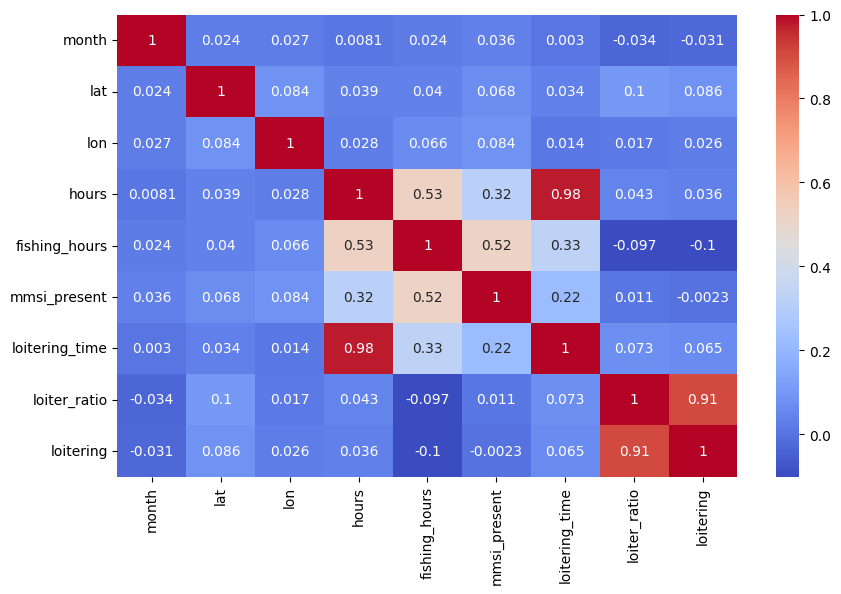

In [7]:
cor= com_df.corr(numeric_only=True)
plt.figure(figsize=(10,6))
sns.heatmap(cor,annot=True,cmap='coolwarm')

In [9]:
flag_list = com_df['flag'].unique()
flag_list

array(['AFG', 'AGO', 'ALB', 'AND', 'ARG', 'ARM', 'ASM', 'ATF', 'ATG',
       'AUS', 'AUT', 'AZE', 'BEL', 'BEN', 'BES', 'BGD', 'BGR', 'BHR',
       'BHS', 'BIH', 'BLZ', 'BMU', 'BOL', 'BRA', 'BRB', 'BRN', 'BTN',
       'CAF', 'CAN', 'CCK', 'CHE', 'CHL', 'CHN', 'CIV', 'CMR', 'COD',
       'COG', 'COK', 'COL', 'COM', 'CPV', 'CRI', 'CUB', 'CYP', 'CZE',
       'DEU', 'DMA', 'DNK', 'ECU', 'EGY', 'ESP', 'EST', 'FIN', 'FJI',
       'FLK', 'FRA', 'FRO', 'FSM', 'GAB', 'GBR', 'GEO', 'GHA', 'GIN',
       'GLP', 'GMB', 'GNB', 'GRC', 'GRD', 'GRL', 'GTM', 'GUY', 'HKG',
       'HND', 'HRV', 'HTI', 'IDN', 'IND', 'IRL', 'IRN', 'IRQ', 'ISL',
       'ISR', 'ITA', 'JOR', 'JPN', 'KAZ', 'KEN', 'KGZ', 'KHM', 'KIR',
       'KNA', 'KOR', 'LBN', 'LBR', 'LCA', 'LIE', 'LKA', 'LSO', 'LTU',
       'LVA', 'MAC', 'MAR', 'MCO', 'MDA', 'MDV', 'MEX', 'MHL', 'MKD',
       'MLI', 'MLT', 'MMR', 'MNE', 'MNG', 'MOZ', 'MRT', 'MTQ', 'MUS',
       'MYS', 'NAM', 'NCL', 'NER', 'NGA', 'NIC', 'NIU', 'NLD', 'NOR',
       'NRU', 'NZL',

In [12]:
countries = [country for country in flag_list if len(country)==3]
unknown = [country for country in flag_list if len(country)!=3]
print("Total Flags : ",len(flag_list))
print("Countries : ",len(countries))
print("Unknown : ",len(unknown))

Total Flags :  288
Countries :  216
Unknown :  72


In [14]:
gear_list = com_df['geartype'].unique()
print(gear_list)

['trawlers' 'fishing' 'set_gillnets' 'other_purse_seines' 'purse_seines'
 'drifting_longlines' 'set_longlines' 'dredge_fishing' 'fixed_gear'
 'tuna_purse_seines' 'squid_jigger' 'pole_and_line' 'pots_and_traps'
 'other_seines' 'trollers' 'seiners']
